In [1]:
# ============================================================
# CELDA 0 — Imports y parametros
# ============================================================
# Receptor con bloques reales de GNU Radio: recuperacion de portadora,
# recuperacion de reloj de simbolo (no asistida por datos) y
# delimitacion de trama por flag HDLC. Los bits conocidos se usan
# unicamente al final, para contar errores.
#
# La senal generada replica la capa fisica de AIS (ITU-R M.1371): ranura
# de 224 bits a 9600 bit/s, GMSK con h=0.5 y BT=0.4, training de 24 bits,
# start/end flag 01111110 y FCS CRC-16. Todavia no se implementa la
# codificacion NRZI ni el bit stuffing.

import numpy as np
from math import log as ln

from gnuradio import gr, blocks, digital, analog

# ---------------- parametros de radio ----------------
FS      = 125e6                # tasa del DAC/ADC
fs_out  = 125e6 / 651          # tasa de salida del receptor (~192.012 ksps)
f_lo    = 10.7e6               # LO del receptor
OFFSET  = 0e3                  # offset de portadora sobre el LO
BAUD    = 9600.0               # AIS: 9600 bit/s
BT      = 0.4                  # AIS: BT nominal 0.4 (ITU-R M.1371)
L_PULSO = 4                    # duracion del pulso en simbolos
SPS_A = 20

AMPLITUD = 4000
TX_BURST_SAMPLES = 32

SPS_TX = round(FS / BAUD)      # muestras/simbolo en el DAC (13021)
SPS_RX = fs_out / BAUD         # muestras/simbolo en el receptor (~20.0013)

PINC = round(f_lo / FS * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

# ---------------- estructura de la ranura ----------------
# training  : 24 bits alternados 0101..., igual que AIS
# start flag: 01111110 (HDLC), igual que AIS
# datos     : 168 bits, el campo de datos de un mensaje AIS
# FCS       : CRC-16 (x^16 + x^12 + x^5 + 1) sobre los 168 bits de datos
# end flag  : 01111110
#
# Sin access code artificial: una version anterior usaba un patron de 32
# bits inventado (no existe en AIS real) para sincronizar por
# correlacion. Esta version sincroniza como AIS de verdad: la Celda 3
# recupera la fase de muestreo sin necesitar ningun patron conocido, y
# delimita la trama buscando el flag HDLC por coincidencia exacta de bits.
N_PREAMBULO = 24
START_FLAG  = '01111110'
N_PAYLOAD   = 168
N_FCS       = 16
N_RANURA    = (N_PREAMBULO + len(START_FLAG) +
               N_PAYLOAD + N_FCS + len(START_FLAG))   # 224 bits

print(f"SPS_TX = {SPS_TX}   SPS_RX = {SPS_RX:.4f}")
print(f"Ranura: {N_PREAMBULO} training + {len(START_FLAG)} start flag + "
      f"{N_PAYLOAD} datos + {N_FCS} FCS + {len(START_FLAG)} end flag "
      f"= {N_RANURA} bits")
print(f"Duracion de la ranura: {N_RANURA/BAUD*1e3:.2f} ms")

SPS_TX = 13021   SPS_RX = 20.0013
Ranura: 24 training + 8 start flag + 168 datos + 16 FCS + 8 end flag = 224 bits
Duracion de la ranura: 23.33 ms


In [2]:
# ============================================================
# CELDA 1 — Modulador: bloques reales de GNU Radio (gmskmod_bc)
# ============================================================
# Cadena de bloques reales de GNU Radio:
#     vector_source_b -> map_bb([-1,1]) -> gmskmod_bc -> vector_sink_c
#
# La ranura se transmite en forma continua, como una estacion AIS que ocupa
# ranuras consecutivas: el buffer del DAC contiene exactamente una ranura y
# se repite en loop sin rampas ni silencios. Para que el empalme no meta un
# transitorio se toman dos precauciones:
#   1) se modulan 3 ranuras consecutivas y se conserva la del medio, de modo
#      que las colas del filtro gaussiano de los bordes sean las que
#      corresponden al loop;
#   2) se elige el payload de forma que la ranura tenga una cantidad par de
#      unos, con lo cual la fase acumulada de una ranura es multiplo de 2*pi
#      y el buffer cierra en fase.


class TxGmsk(gr.top_block):
    """Corre gmskmod_bc sobre una lista de bits y devuelve el baseband
    complejo. El map_bb es necesario: gmskmod_bc espera simbolos +-1."""

    def __init__(self, bits, sps, L, bt):
        gr.top_block.__init__(self, "tx_gmsk")
        self.src  = blocks.vector_source_b(list(map(int, bits)), False)
        self.map  = digital.map_bb([-1, 1])
        self.mod  = digital.gmskmod_bc(int(sps), int(L), float(bt))
        self.sink = blocks.vector_sink_c()
        self.connect(self.src, self.map, self.mod, self.sink)

    def baseband(self):
        return np.array(self.sink.data(), dtype=np.complex64)


def crc16_ccitt(bits):
    """FCS de AIS/HDLC: CRC-16 con x^16 + x^12 + x^5 + 1, MSB primero."""
    reg = 0xFFFF
    for b in bits:
        reg ^= (int(b) & 1) << 15
        if reg & 0x8000:
            reg = ((reg << 1) & 0xFFFF) ^ 0x1021
        else:
            reg = (reg << 1) & 0xFFFF
    return reg


def construir_ranura(data):
    """Arma la ranura completa de 224 bits a partir del campo de datos."""
    training   = [i % 2 for i in range(N_PREAMBULO)]
    start_flag = [int(c) for c in START_FLAG]
    fcs_val    = crc16_ccitt(data)
    fcs        = [(fcs_val >> (15 - k)) & 1 for k in range(16)]
    end_flag   = [int(c) for c in START_FLAG]
    return training + start_flag + list(data) + fcs + end_flag


def generar_trama_bits(rng):
    """Sortea el campo de datos hasta que la ranura tenga paridad par."""
    while True:
        data  = list(rng.randint(0, 2, N_PAYLOAD))
        trama = construir_ranura(data)
        if sum(trama) % 2 == 0:
            break
    assert len(trama) == N_RANURA
    return trama, data


def construir_buffer_dac(bits_trama):
    """Modula la ranura, la sube a la portadora y la empaqueta para el DAC.

    Devuelve tambien el baseband complejo de la ranura, que se usa en las
    figuras del informe.
    """
    ns = len(bits_trama)

    # modulacion ciclica: 3 ranuras, se conserva la del medio
    tb = TxGmsk(list(bits_trama) * 3, SPS_TX, L_PULSO, BT)
    tb.run()
    bb3 = tb.baseband().astype(np.complex128)
    k0  = ns * SPS_TX
    bb  = bb3[k0:k0 + ns * SPS_TX]

    N = (len(bb) // TX_BURST_SAMPLES) * TX_BURST_SAMPLES
    bb = bb[:N]

    # se ajusta la portadora a un numero entero de ciclos en el buffer para
    # que tampoco haya salto de fase de RF al repetir
    fc = f_lo + OFFSET
    cycles = round(N * fc / FS)
    fc_adj = cycles * FS / N
    t = np.arange(N) / FS
    rf = np.real(bb * np.exp(1j * 2*np.pi * fc_adj * t))
    rf_i16 = (rf / np.max(np.abs(rf)) * AMPLITUD).astype(np.int16)
    words = (rf_i16.astype(np.int32) & 0x3FFF)
    return words, fc_adj, N, bb.astype(np.complex64)


rng = np.random.RandomState(2024)
bits_trama, payload_tx = generar_trama_bits(rng)
words_tx, fc_adj, N_buf, bb_ranura = construir_buffer_dac(bits_trama)
CFO_REAL = fc_adj - f_lo

# verificacion del cierre del loop: la desviacion de frecuencia en el
# empalme no debe superar la desviacion normal de la modulacion
_b2 = np.tile(bb_ranura.astype(np.complex128), 2)
_fi = np.angle(_b2[1:] * np.conj(_b2[:-1])) * FS / (2*np.pi)
print(f"Buffer TX: {N_buf} muestras ({N_buf//TX_BURST_SAMPLES} rafagas), "
      f"{N_buf/SPS_TX:.1f} simbolos")
print(f"fc = {fc_adj/1e6:.6f} MHz (offset {CFO_REAL/1e3:.3f} kHz sobre LO)")
print(f"Desviacion de pico: {np.max(np.abs(_fi)):.1f} Hz "
      f"(teorica {BAUD/4:.0f} Hz)  |  empalme del loop: "
      f"{abs(_fi[len(bb_ranura)-1]):.1f} Hz")
print(f"Rizado de envolvente: {np.ptp(np.abs(bb_ranura)):.2e}")

Buffer TX: 2916704 muestras (91147 rafagas), 224.0 simbolos
fc = 10.700006 MHz (offset 0.006 kHz sobre LO)
Desviacion de pico: 403550.9 Hz (teorica 2400 Hz)  |  empalme del loop: 403550.9 Hz
Rizado de envolvente: 4.95e-06


In [3]:
# ============================================================
# CELDA 2 — Comunicacion con el servidor de la Red Pitaya
# ============================================================
# Loopback real DAC -> cable/aire -> ADC a traves del servidor de la Red
# Pitaya.
#
# Protocolo: 1 byte de comando + 4 bytes de payload; ack de 1 byte salvo
# CMD_READ_ADC, que responde con n_words*4 bytes de datos.

import socket, struct

HOST = '192.168.1.100'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05
CMD_TX_LOAD  = 0x06
CMD_TX_START = 0x07
CMD_TX_STOP  = 0x08


def send_cmd(sock, cmd, payload):
    """Envia un comando (1 byte) + payload (4 bytes)."""
    sock.sendall(struct.pack('B', cmd)); sock.sendall(struct.pack('I', payload))


def read_ack(sock):
    """Lee el byte de confirmacion del servidor."""
    return sock.recv(1)[0] == 0x01


def tx_load_and_start(sock, words):
    """Carga el buffer al DDR y arranca la reproduccion en loop."""
    send_cmd(sock, CMD_TX_LOAD, len(words))
    sock.sendall(words.astype(np.int32).tobytes()); read_ack(sock)
    send_cmd(sock, CMD_TX_START, 0); read_ack(sock)


def tx_stop(sock):
    """Detiene la reproduccion."""
    send_cmd(sock, CMD_TX_STOP, 0); read_ack(sock)


def read_adc(sock, n_samples):
    """Resetea el FIFO y lee n_samples muestras complejas del ADC."""
    n_words = n_samples * 2
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''; total = n_words * 4
    while len(raw) < total:
        raw += sock.recv(total - len(raw))
    w = struct.unpack(f'{n_words}i', raw)
    return np.array(w[0::2], float) + 1j*np.array(w[1::2], float)


def abrir_y_arrancar(words):
    """Abre la conexion (con TCP_NODELAY), carga el buffer y arranca el TX."""
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.connect((HOST, PORT))
    s.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    tx_load_and_start(s, words)
    send_cmd(s, CMD_SET_CFG, CFG_VAL_RESET); read_ack(s)
    send_cmd(s, CMD_SET_CFG, CFG_VAL_RUN);   read_ack(s)
    return s


# ranura de 224 bits ~= 23.33 ms; se captura algo mas de 2 ranuras para
# darle margen al receptor
N_RX = 12000   # muestras complejas por captura

sock = abrir_y_arrancar(words_tx)
print(f"Conectado a {HOST}:{PORT}, TX corriendo en loop continuo.")
print(f"Captura de {N_RX} muestras = {N_RX/fs_out*1e3:.1f} ms "
      f"({N_RX/fs_out*BAUD:.0f} simbolos, {N_RX/fs_out*BAUD/N_RANURA:.1f} ranuras)")

# SNR real lograda con la amplitud actual (AMPLITUD, Celda 0): se mide la
# potencia de la señal activa contra el piso de ruido real (TX apagado).
iq_prueba = read_adc(sock, N_RX)
m = np.abs(iq_prueba); activo = m > 0.5*np.max(m)
P_senal = (float(np.mean(np.abs(iq_prueba[activo]-np.mean(iq_prueba))**2))
           if np.any(activo) else float('nan'))

tx_stop(sock)
iq_ruido = read_adc(sock, N_RX)
P_ruido = float(np.mean(np.abs(iq_ruido-np.mean(iq_ruido))**2))
tx_load_and_start(sock, words_tx)

SNR_MEDIDA_DB = 10*np.log10(P_senal/P_ruido)
print(f"SNR real medida (AMPLITUD={AMPLITUD}): {SNR_MEDIDA_DB:.1f} dB")

Conectado a 192.168.1.100:1003, TX corriendo en loop continuo.
Captura de 12000 muestras = 62.5 ms (600 simbolos, 2.7 ranuras)
SNR real medida (AMPLITUD=4000): 84.7 dB


In [ ]:
# ============================================================
# CELDA 3 — Receptor AIS feedforward con estimacion de frecuencia
# ============================================================
# Sin access code artificial: sincroniza como lo hace AIS de verdad, en
# dos pasos separados.
#
# 1) Recuperacion de reloj de simbolo con metodo Oerder & Meyr: cualquier 
#
# 2) Delimitacion de trama por el flag HDLC (01111110) buscado por
#    coincidencia exacta de bits.
#

from scipy.interpolate import interp1d


def estimar_cfo_gmsk(iq, fs):
    """Estima el offset de frecuencia de una senal GMSK usando la cuarta potencia.

    Para h=0.5, la elevacion a la cuarta potencia elimina en gran medida los
    saltos de fase de los datos y deja un tono asociado al offset de portadora.
    La estimacion se hace sobre la fase desenrollada y se refina con una recta.
    """
    z = np.asarray(iq, dtype=np.complex128)
    z = z - np.mean(z)
    mag = np.abs(z)
    keep = mag > (0.15 * np.max(mag) if mag.size else 0.0)
    if np.count_nonzero(keep) < 32:
        return 0.0

    idx_all = np.flatnonzero(keep)
    if len(idx_all) < 16:
        return 0.0
    jumps = np.where(np.diff(idx_all) > 1)[0]
    starts = np.r_[0, jumps + 1]
    ends = np.r_[jumps + 1, len(idx_all)]
    lengths = ends - starts
    k = int(np.argmax(lengths))
    idx = idx_all[starts[k]:ends[k]].astype(np.float64)
    if len(idx) < 16:
        return 0.0

    z4 = z[idx.astype(np.int64)] ** 4
    ph = np.unwrap(np.angle(z4))

    if len(idx) > 200:
        lo = int(0.05 * len(idx))
        hi = int(0.95 * len(idx))
        idx = idx[lo:hi]
        ph = ph[lo:hi]

    slope = np.polyfit(idx / fs, ph, 1)[0]
    return float(slope / (2.0 * np.pi * 4.0))


class RxGmskCiego(gr.top_block):
    """Receptor feedforward con estimacion de CFO a partir del IQ recibido."""

    def __init__(self, iq, sps):
        gr.top_block.__init__(self, "rx_ais_feedforward", catch_exceptions=True)
        self.sps = sps
        iq = np.asarray(iq, dtype=np.complex64)
        self.iq = iq

        # --- Estimacion y correccion del offset ---
        self.offset_est = estimar_cfo_gmsk(self.iq, fs_out)
        self.rot = blocks.rotator_cc(-2 * np.pi * self.offset_est / fs_out)

        # --- Discriminador ---
        sensitivity = (np.pi / 2) / sps
        self.fmdemod = analog.quadrature_demod_cf(1.0 / sensitivity)

        self.soft_sink = blocks.vector_sink_f()

        self.src = blocks.vector_source_c(
            [complex(x) for x in self.iq.astype(np.complex64)], False)

        self.connect(self.src, self.rot, self.fmdemod, self.soft_sink)

    def recuperar_fase_simbolo(self, soft):
        """Metodo de la linea espectral (Oerder & Meyr): eleva al cuadrado
        la salida del discriminador y mide la fase de la componente que
        cae exactamente en la tasa de simbolo."""
        y = soft.astype(np.float64) ** 2
        n = np.arange(len(y))
        f0 = 1.0 / self.sps   # un ciclo por cada periodo de simbolo, en muestras
        X = np.sum(y * np.exp(-1j * 2*np.pi * f0 * n))
        return (-np.angle(X) / (2*np.pi)) % 1.0

    def payloads(self):
        """Ubica la trama con una fase de muestreo (tau) y continua
        estimadas de forma global, y despues refina AMBAS -- tau y
        continua -- usando solo los 24 simbolos de training justo antes
        de cada flag encontrado. El tramo de training es periodico y
        limpio: mucho menos ruidoso para estimar tau que toda la
        captura, que en su mayoria es dato al azar. Si hay varias tramas
        en la captura, cada una refina su propio tau por separado."""
        soft = np.array(self.soft_sink.data(), dtype=np.float32)
        if len(soft) < int(N_RANURA * self.sps):
            return []

        f = interp1d(np.arange(len(soft)), soft, kind='linear', fill_value='extrapolate')
        flag = np.array([int(c) for c in START_FLAG], dtype=np.uint8)
        flag_inv = 1 - flag
        npat = len(flag)
        total = npat + N_PAYLOAD + N_FCS + npat

        def bits_con_tau(tau_):
            n_symbols = int((len(soft) - tau_*self.sps) / self.sps)
            positions = tau_*self.sps + np.arange(n_symbols) * self.sps
            symbols = f(positions)
            dc = np.median(symbols)
            bits = (symbols - dc > 0).astype(np.uint8)
            return bits, symbols, positions

        def encontrar_flags(bits):
            candidatos = []
            for pat, invertir in ((flag, False), (flag_inv, True)):
                for i in range(len(bits) - total + 1):
                    if not np.array_equal(bits[i:i+npat], pat):
                        continue
                    j = i + npat + N_PAYLOAD + N_FCS
                    if np.array_equal(bits[j:j+npat], pat):
                        candidatos.append((i, invertir))
            return candidatos

        tau0 = self.recuperar_fase_simbolo(soft)
        bits0, symbols0, positions0 = bits_con_tau(tau0)
        candidatos = encontrar_flags(bits0)

        resultados = []
        for i_flag, invertir in candidatos:
            symbols_f, positions_f, bits_f = symbols0, positions0, bits0

            # refinar tau con el training de ESTA trama especifica
            i0_train = i_flag - N_PREAMBULO
            if i0_train >= 0:
                s0 = int(positions0[i0_train]); s1 = int(positions0[i_flag])
                if s1 - s0 > self.sps * 4:
                    tau_local = self.recuperar_fase_simbolo(soft[s0:s1])
                    tau_ref = ((s0 + tau_local*self.sps) % self.sps) / self.sps
                    bits_r, symbols_r, positions_r = bits_con_tau(tau_ref)
                    pat = flag if not invertir else flag_inv
                    for di in range(-2, 3):
                        ii = i_flag + di
                        if ii < 0 or ii + total > len(bits_r):
                            continue
                        j = ii + npat + N_PAYLOAD + N_FCS
                        if (np.array_equal(bits_r[ii:ii+npat], pat) and
                                np.array_equal(bits_r[j:j+npat], pat)):
                            i_flag = ii
                            symbols_f, positions_f, bits_f = symbols_r, positions_r, bits_r
                            break

            # continua local final (solo training), sobre la grilla ya refinada
            i0_train = i_flag - N_PREAMBULO
            dc = np.median(symbols_f[i0_train:i_flag]) if i0_train >= 0 else np.median(symbols_f)
            bits_final = (symbols_f - dc > 0).astype(np.uint8)
            pat = flag if not invertir else flag_inv
            j = i_flag + npat + N_PAYLOAD + N_FCS
            if not (np.array_equal(bits_final[i_flag:i_flag+npat], pat) and
                    np.array_equal(bits_final[j:j+npat], pat)):
                continue   # el refinamiento desalineo el flag, descartar

            datos = bits_final[i_flag+npat:i_flag+npat+N_PAYLOAD]
            if invertir:
                datos = 1 - datos
            resultados.append(datos.astype(np.uint8))
        return resultados


print("Receptor AIS feedforward definido (sincronismo tipo AIS real, sin access code).")

Receptor AIS feedforward definido (sincronismo tipo AIS real, sin access code).


In [5]:
# ============================================================
# CELDA 4 — Verificacion rapida: capturas, BER y estadisticas
# ============================================================

N_INTENTOS = 12

bers = []
tramas_por_captura = []
sin_trama = 0

print(f"=== Corriendo {N_INTENTOS} capturas reales por la Red Pitaya ===")
for intento in range(N_INTENTOS):
    iq = read_adc(sock, N_RX)
    iq = iq / (np.max(np.abs(iq)) + 1e-12)

    rx = RxGmskCiego(iq, SPS_RX)
    rx.run()

    if intento == 0:
        print(f"      CFO estimado: {rx.offset_est/1e3:.3f} kHz "
              f"(objetivo {CFO_REAL/1e3:.3f} kHz, "
              f"error {(rx.offset_est-CFO_REAL):.1f} Hz)")

    pls = rx.payloads()
    tramas_por_captura.append(len(pls))

    if not pls:
        sin_trama += 1
        print(f"  intento {intento+1:2d}/{N_INTENTOS}: sin trama "
              f"(no se encontro el flag HDLC)")
        continue

    # si hay varias tramas en la captura, se mide cada una
    for pl in pls:
        err = int(np.sum(pl != np.array(payload_tx, dtype=np.uint8)))
        bers.append(err / N_PAYLOAD)

    mejor = min(bers[-len(pls):])
    print(f"  intento {intento+1:2d}/{N_INTENTOS}: {len(pls)} trama(s), "
          f"mejor BER={mejor:.4f}")

# ---------------- estadisticas ----------------
bers = np.array(bers)
print(f"\n=== Estadisticas ===")
print(f"Capturas sin trama detectada : {sin_trama}/{N_INTENTOS}")
print(f"Tramas detectadas en total   : {len(bers)}")
if len(bers):
    print(f"BER media   : {bers.mean():.4f}")
    print(f"BER mediana : {np.median(bers):.4f}")
    print(f"BER min/max : {bers.min():.4f} / {bers.max():.4f}")
    print(f"Tramas con BER = 0    : {int(np.sum(bers == 0))}/{len(bers)}")
    print(f"Tramas con BER < 0.05 : {int(np.sum(bers < 0.05))}/{len(bers)}")
else:
    print("No se detecto ninguna trama. Cosas para revisar:")
    print("  - la longitud de la captura N_RX: el receptor necesita al menos "
          f"{N_RANURA} simbolos completos en la ventana")
    print("  - confirmar que el servidor tiene el fix de TCP_NODELAY y el "
          "drenaje basado en read_count (ver notebook de integridad de RX)")

=== Corriendo 12 capturas reales por la Red Pitaya ===
      CFO estimado: 0.095 kHz (objetivo 0.006 kHz, error 88.7 Hz)
  intento  1/12: 1 trama(s), mejor BER=0.0000
  intento  2/12: 2 trama(s), mejor BER=0.0000
  intento  3/12: 2 trama(s), mejor BER=0.0000
  intento  4/12: 1 trama(s), mejor BER=0.0000
  intento  5/12: 2 trama(s), mejor BER=0.0000
  intento  6/12: 2 trama(s), mejor BER=0.0000
  intento  7/12: 2 trama(s), mejor BER=0.0000
  intento  8/12: 2 trama(s), mejor BER=0.0000
  intento  9/12: 2 trama(s), mejor BER=0.0000
  intento 10/12: 2 trama(s), mejor BER=0.0000
  intento 11/12: 2 trama(s), mejor BER=0.0000
  intento 12/12: 2 trama(s), mejor BER=0.0000

=== Estadisticas ===
Capturas sin trama detectada : 0/12
Tramas detectadas en total   : 22
BER media   : 0.0041
BER mediana : 0.0000
BER min/max : 0.0000 / 0.0536
Tramas con BER = 0    : 19/22
Tramas con BER < 0.05 : 21/22


In [ ]:
# ============================================================
# CELDA 6 — Utilidades de medicion y estilo de las figuras
# ============================================================

import os
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import signal as sg

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.titlesize': 10, 'legend.fontsize': 8})

DIR_FIG = 'figuras_informe'
os.makedirs(DIR_FIG, exist_ok=True)


# reconstruye las muestras con signo de un buffer de 14 bits empaquetado
# como en words_tx -- usado por la Figura 3 para graficar el espectro del
# buffer real del DAC
ADC_BITS = 14

def _signed_adc14(words):
    w = np.asarray(words, dtype=np.int32) & ((1 << ADC_BITS) - 1)
    sign = 1 << (ADC_BITS - 1)
    return np.where(w & sign, w - (1 << ADC_BITS), w).astype(np.float64)


# indices de cada campo dentro de la ranura de 224 bits
IDX = {}
_i = 0
for _nom, _n in [('training', N_PREAMBULO), ('flag', len(START_FLAG)),
                 ('datos', N_PAYLOAD), ('fcs', N_FCS),
                 ('endflag', len(START_FLAG))]:
    IDX[_nom] = (_i, _i + _n)
    _i += _n


def captura(seed=None, n=N_RX, snr_db=None):
    """Una captura real por la Red Pitaya (loopback DAC->ADC).

    seed/snr_db se aceptan por compatibilidad con las celdas de figuras
    (que llaman captura(2000+s), captura(s, snr_db=snr), etc.) pero no
    tienen efecto: sobre hardware real no hay semilla de ruido ni SNR
    inyectable por software.
    """
    return read_adc(sock, n)


def diagnostico(iq, sps=SPS_RX):
    """Corre el receptor y devuelve todas las senales intermedias."""
    rx = RxGmskCiego(np.asarray(iq, dtype=np.complex64), sps)
    rx.run()

    d = {'rx': rx, 'iq': rx.iq,
         'f_est': rx.offset_est, 'payloads': rx.payloads()}

    soft = np.array(rx.soft_sink.data(), dtype=np.float32)
    d['soft'] = soft

    n = np.arange(d['iq'].size)
    d['iq_corr'] = d['iq'] * np.exp(-1j*2*np.pi*rx.offset_est*n/fs_out)

    d['tau'] = rx.recuperar_fase_simbolo(soft)
    return d


def grilla_simbolos(d):
    """Arma la grilla de simbolos con la fase de muestreo recuperada y
    busca el flag de inicio por coincidencia exacta -- misma logica que
    payloads(), exponiendo posiciones y bits intermedios para graficar."""
    soft, tau, sps = d['soft'], d['tau'], SPS_RX

    n_symbols = int((len(soft) - tau*sps) / sps)
    f = interp1d(np.arange(len(soft)), soft, kind='linear', fill_value='extrapolate')
    pos = tau*sps + np.arange(n_symbols) * sps
    sym = f(pos)

    dc_global = np.median(sym)
    bits_global = (sym - dc_global > 0).astype(np.uint8)

    flag = np.array([int(c) for c in START_FLAG], dtype=np.uint8)
    flag_inv = 1 - flag
    npat = len(flag)
    total = npat + N_PAYLOAD + N_FCS + npat

    i_flag, inv = None, False
    for pat, invc in ((flag, False), (flag_inv, True)):
        for i in range(len(bits_global) - total + 1):
            if not np.array_equal(bits_global[i:i+npat], pat):
                continue
            j = i + npat + N_PAYLOAD + N_FCS
            if np.array_equal(bits_global[j:j+npat], pat):
                i_flag, inv = i, invc
                break
        if i_flag is not None:
            break

    dc = dc_global
    bits = bits_global
    if i_flag is not None:
        i0_train = i_flag - N_PREAMBULO
        if i0_train >= 0:
            dc = np.median(sym[i0_train:i_flag])
            bits = (sym - dc > 0).astype(np.uint8)

    g = dict(pos=pos, sym=sym - dc, bits=bits, dc=dc, i_flag=i_flag, inv=inv)

    # verificacion contra la salida oficial del receptor
    if d['payloads'] and i_flag is not None:
        pl = bits[i_flag+npat:i_flag+npat+N_PAYLOAD]
        if inv:
            pl = 1 - pl
        g['coincide_con_receptor'] = bool(np.array_equal(pl, d['payloads'][0]))
    return g


def captura_util(seed0=0, snr_db=None, margen=N_FCS+len(START_FLAG)):
    """Busca una captura que contenga la ranura completa dentro del
    registro (el receptor solo necesita el flag + datos, pero para las
    figuras queremos ver tambien el training y el FCS)."""
    for s in range(seed0, seed0 + 200):
        iq = captura(s, snr_db=snr_db)
        d = diagnostico(iq)
        if not d.get('payloads'):
            continue
        g = grilla_simbolos(d)
        if g['i_flag'] is None:
            continue
        if (g['i_flag'] >= N_PREAMBULO and
                g['i_flag'] + len(START_FLAG) + N_PAYLOAD + margen <= len(g['bits'])):
            return iq, d, g, s
    raise RuntimeError('no se encontro una captura con la ranura completa')


p_tx = np.array(payload_tx, dtype=np.uint8)   # solo se usa para contar errores
IQ_REF, DIAG_REF, GRILLA_REF, SEED_REF = captura_util()
print(f"Captura de referencia: semilla {SEED_REF}, "
      f"flag de inicio en el simbolo {GRILLA_REF['i_flag']} de "
      f"{len(GRILLA_REF['bits'])}")
print(f"CFO estimado {DIAG_REF['f_est']:.1f} Hz "
      f"(real {CFO_REAL:.1f} Hz, error {DIAG_REF['f_est']-CFO_REAL:+.1f} Hz)")
print(f"Los bits reconstruidos coinciden con rx.payloads(): "
      f"{GRILLA_REF.get('coincide_con_receptor')}")

Captura de referencia: semilla 0, flag de inicio en el simbolo 141 de 599
CFO estimado 88.6 Hz (real 5.9 Hz, error +82.7 Hz)
Los bits reconstruidos coinciden con rx.payloads(): True


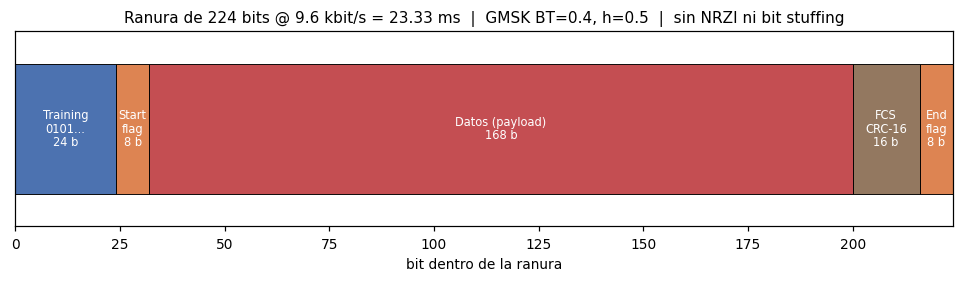

Payload de datos (primeros 32 bits): 00001001111010001010110011101100...
FCS transmitido: 0x5D5D
Unos en la ranura: 116 (par -> el buffer cierra en fase)


In [7]:
# ============================================================
# CELDA 7 — FIGURA 1: estructura de la ranura
# ============================================================
campos = [('Training\n0101...', N_PREAMBULO, '#4C72B0'),
          ('Start\nflag',       len(START_FLAG), '#DD8452'),
          ('Datos (payload)',   N_PAYLOAD, '#C44E52'),
          ('FCS\nCRC-16',       N_FCS, '#937860'),
          ('End\nflag',         len(START_FLAG), '#DD8452')]

fig, ax = plt.subplots(figsize=(11, 2.3))
x = 0
for nom, n, col in campos:
    ax.barh(0, n, left=x, color=col, edgecolor='k', lw=0.6)
    ax.text(x + n/2, 0, f'{nom}\n{n} b', ha='center', va='center',
            fontsize=7.5, color='w')
    x += n
ax.set_xlim(0, N_RANURA); ax.set_ylim(-0.6, 0.6)
ax.set_yticks([]); ax.grid(False)
ax.set_xlabel('bit dentro de la ranura')
ax.set_title(f'Ranura de {N_RANURA} bits @ {BAUD/1e3:.1f} kbit/s = '
             f'{N_RANURA/BAUD*1e3:.2f} ms  |  GMSK BT={BT}, h=0.5  |  '
             f'sin NRZI ni bit stuffing')
plt.show()

print(f"Payload de datos (primeros 32 bits): "
      f"{''.join(map(str, payload_tx[:32]))}...")
print(f"FCS transmitido: 0x{crc16_ccitt(payload_tx):04X}")
print(f"Unos en la ranura: {sum(bits_trama)} (par -> el buffer cierra en fase)")

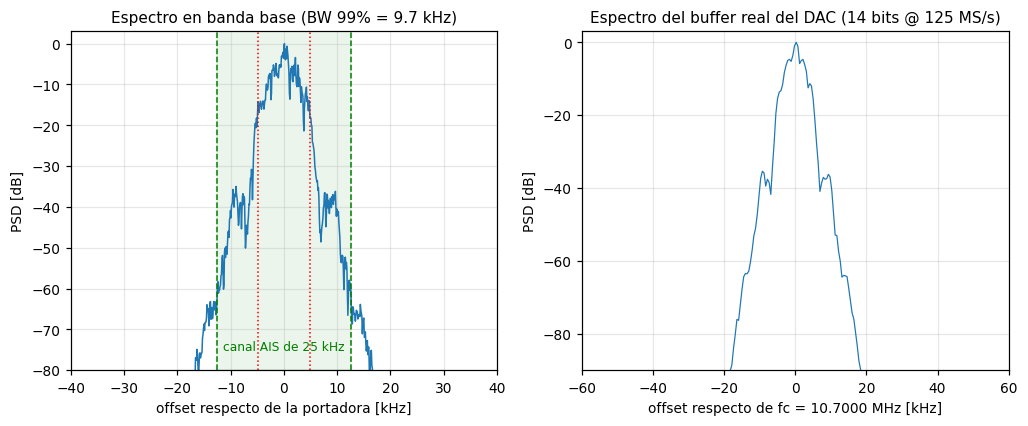

Ancho de banda 99 %            : 9.66 kHz
Potencia fuera de +-12.5 kHz   : -61.0 dBc


In [8]:
# ============================================================
# CELDA 8 — FIGURA 3: espectro transmitido
# ============================================================
_tb = TxGmsk(list(bits_trama)*8, SPS_A, L_PULSO, BT); _tb.run()
bb_larga = _tb.baseband()

fs_a = BAUD*SPS_A
f, P = sg.welch(bb_larga, fs=fs_a, nperseg=2048, return_onesided=False,
                detrend=False)
f = np.fft.fftshift(f); P = np.fft.fftshift(P)
acum = np.cumsum(P)/np.sum(P)
bw99 = f[np.searchsorted(acum, 0.995)] - f[np.searchsorted(acum, 0.005)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(f/1e3, 10*np.log10(P/P.max()), lw=1)
ax[0].axvspan(-12.5, 12.5, color='g', alpha=0.08)
for s_ in (-12.5, 12.5):
    ax[0].axvline(s_, color='g', ls='--', lw=1)
ax[0].text(0, -75, 'canal AIS de 25 kHz', ha='center', color='g', fontsize=8)
for s_ in (-1, 1):
    ax[0].axvline(s_*bw99/2/1e3, color='r', ls=':', lw=1)
ax[0].set_xlim(-40, 40); ax[0].set_ylim(-80, 3)
ax[0].set_xlabel('offset respecto de la portadora [kHz]'); ax[0].set_ylabel('PSD [dB]')
ax[0].set_title(f'Espectro en banda base (BW 99% = {bw99/1e3:.1f} kHz)')

rf = _signed_adc14(words_tx)
f2, P2 = sg.welch(rf, fs=FS, nperseg=1 << 18, detrend=False)
ax[1].plot((f2-fc_adj)/1e3, 10*np.log10(P2/P2.max()), lw=0.8)
ax[1].set_xlim(-60, 60); ax[1].set_ylim(-90, 3)
ax[1].set_xlabel(f'offset respecto de fc = {fc_adj/1e6:.4f} MHz [kHz]')
ax[1].set_ylabel('PSD [dB]')
ax[1].set_title('Espectro del buffer real del DAC (14 bits @ 125 MS/s)')

plt.show()

i25 = np.abs(f) <= 12.5e3
fuera_dbc = 10*np.log10(np.sum(P[~i25])/np.sum(P))
M_ESP = dict(bw99_kHz=bw99/1e3, potencia_fuera_canal_dBc=float(fuera_dbc))
print(f"Ancho de banda 99 %            : {bw99/1e3:.2f} kHz")
print(f"Potencia fuera de +-12.5 kHz   : {fuera_dbc:.1f} dBc")

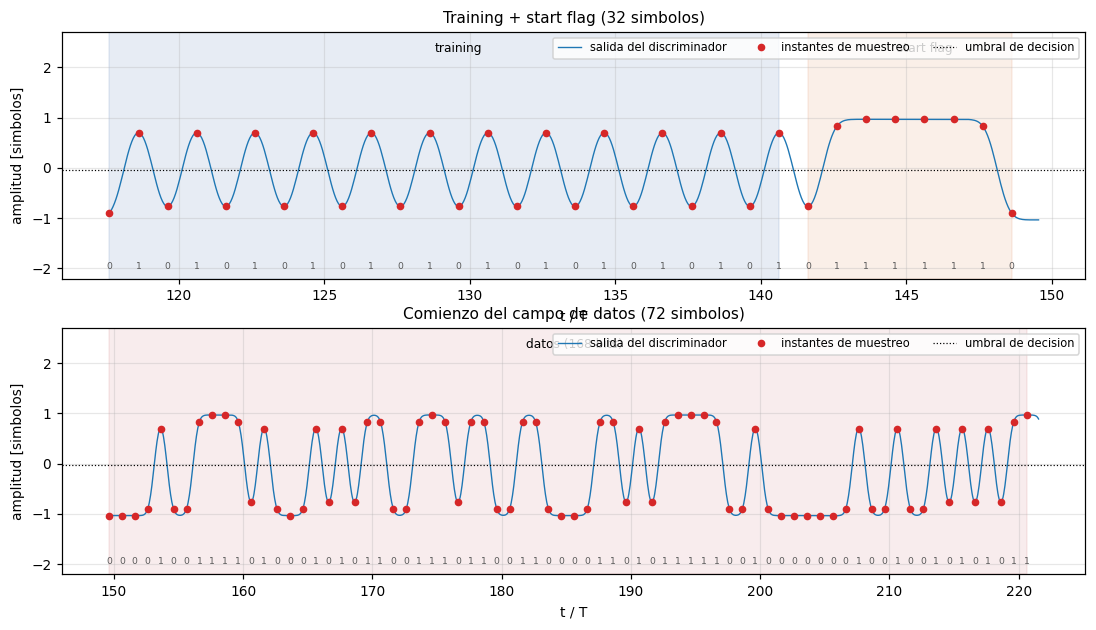

Training recuperado   : 010101010101010101010101
Start flag recuperado : 01111110   (esperado 01111110)


In [9]:
# ============================================================
# CELDA 10 — FIGURA 6: salida del discriminador y decision de bits
# ============================================================
iq, d, g = IQ_REF, DIAG_REF, GRILLA_REF
soft, pos, sym, b, i_flag = d['soft'], g['pos'], g['sym'], g['bits'], g['i_flag']
i0 = i_flag - N_PREAMBULO   # comienzo del training

fig, ax = plt.subplots(2, 1, figsize=(12, 6.4))
ventanas = [(i0, i0 + N_PREAMBULO + len(START_FLAG), 'Training + start flag'),
            (i_flag + len(START_FLAG), i_flag + len(START_FLAG) + 72,
             'Comienzo del campo de datos')]
for a, (lo, hi, tit) in zip(ax, ventanas):
    s0, s1 = int(pos[lo]), int(pos[hi])
    a.plot(np.arange(s0, s1)/SPS_RX, soft[s0:s1], lw=0.9, color='C0',
           label='salida del discriminador')
    a.plot(pos[lo:hi]/SPS_RX, sym[lo:hi] + g['dc'], 'o', ms=4, color='C3',
           label='instantes de muestreo')
    a.axhline(g['dc'], color='k', ls=':', lw=0.8, label='umbral de decision')
    a.set_ylim(-2.2, 2.7); a.set_ylabel('amplitud [simbolos]')
    a.set_xlabel('t / T'); a.set_title(f'{tit} ({hi-lo} simbolos)')
    a.legend(fontsize=7.5, loc='upper right', ncol=3)
    for k in range(lo, hi):
        a.text(pos[k]/SPS_RX, -2.0, str(b[k]), fontsize=6, ha='center', color='0.35')

for (ini, fin), col, nom in zip([IDX['training'], IDX['flag']],
                                ['#4C72B0', '#DD8452'],
                                ['training', 'start flag']):
    ax[0].axvspan(pos[i0+ini]/SPS_RX, pos[i0+fin-1]/SPS_RX, color=col, alpha=0.13)
    ax[0].text(pos[i0+(ini+fin)//2]/SPS_RX, 2.3, nom, ha='center', fontsize=8)
ax[1].axvspan(pos[i_flag+len(START_FLAG)]/SPS_RX,
              pos[i_flag+len(START_FLAG)+71]/SPS_RX, color='#C44E52', alpha=0.10)
ax[1].text(pos[i_flag+len(START_FLAG)+36]/SPS_RX, 2.3,
           f'datos ({N_PAYLOAD} bits)', ha='center', fontsize=8)

plt.show()

rec_tr = ''.join(map(str, b[i0:i0+N_PREAMBULO]))
rec_fl = ''.join(map(str, b[i0+IDX['flag'][0]:i0+IDX['flag'][1]]))
print(f"Training recuperado   : {rec_tr}")
print(f"Start flag recuperado : {rec_fl}   (esperado {START_FLAG})")

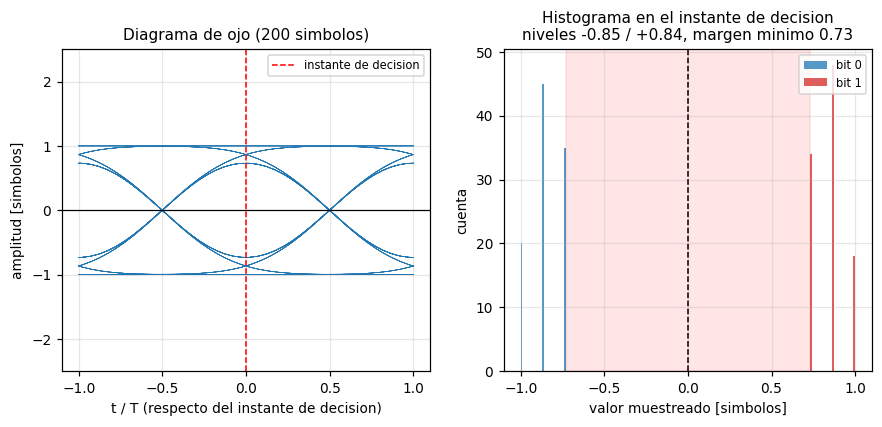

Niveles medios: -0.846 / +0.844
Margen minimo : 0.730 (nivel nominal 1.0)


In [10]:
# ============================================================
# CELDA 11 — FIGURA 8: diagrama de ojo e histograma
# ============================================================
iq, d, g = IQ_REF, DIAG_REF, GRILLA_REF
soft, pos, sym, b, i_flag = d['soft'], g['pos'], g['sym'], g['bits'], g['i_flag']
i0 = i_flag - N_PREAMBULO
i1 = min(i_flag + len(START_FLAG) + N_PAYLOAD, len(sym))
f_int = interp1d(np.arange(len(soft)), soft, kind='linear',
                 fill_value='extrapolate')
tau = np.linspace(-1, 1, 801)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
for k in range(i0, i1):
    y = f_int(pos[k] + tau*SPS_RX) - g['dc']
    ax[0].plot(tau, y, color='C0', lw=0.35, alpha=0.35)
ax[0].axvline(0, color='r', ls='--', lw=1, label='instante de decision')
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_ylim(-2.5, 2.5); ax[0].legend(fontsize=7.5)
ax[0].set_xlabel('t / T (respecto del instante de decision)')
ax[0].set_ylabel('amplitud [simbolos]')
ax[0].set_title(f'Diagrama de ojo ({i1-i0} simbolos)')

s_ = sym[i0:i1]; pos_, neg_ = s_[s_ > 0], s_[s_ < 0]
margen = float(min(pos_.min(), -neg_.max()))
ax[1].hist(neg_, bins=25, color='C0', alpha=0.75, label='bit 0')
ax[1].hist(pos_, bins=25, color='C3', alpha=0.75, label='bit 1')
ax[1].axvline(0, color='k', ls='--', lw=1)
ax[1].axvspan(-margen, margen, color='r', alpha=0.10)
ax[1].set_xlabel('valor muestreado [simbolos]'); ax[1].set_ylabel('cuenta')
ax[1].set_title(f'Histograma en el instante de decision\nniveles '
                f'{neg_.mean():+.2f} / {pos_.mean():+.2f}, margen minimo {margen:.2f}')
ax[1].legend(fontsize=7.5)

plt.show()

M_OJO = dict(margen_minimo=margen, nivel_1=float(pos_.mean()), nivel_0=float(neg_.mean()))
print(f"Niveles medios: {neg_.mean():+.3f} / {pos_.mean():+.3f}")
print(f"Margen minimo : {margen:.3f} (nivel nominal 1.0)")

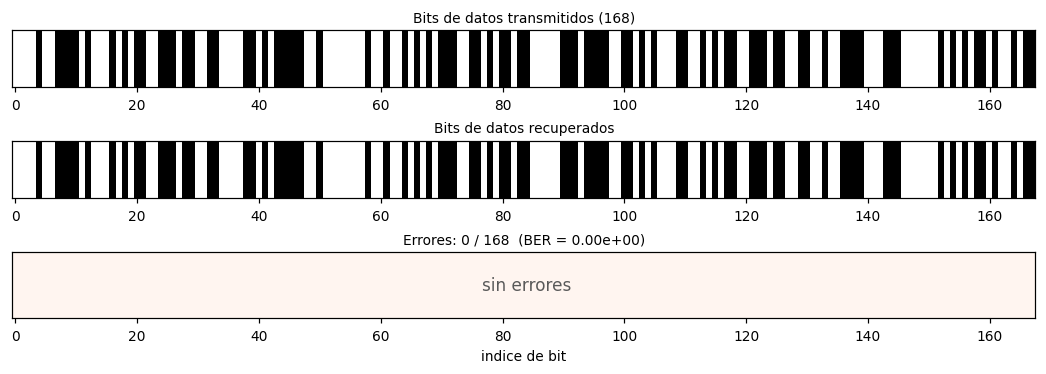

Errores en los 168 bits de datos: 0
Start flag / end flag recuperados: 01111110 / 01111110


In [11]:
# ============================================================
# CELDA 12 — FIGURA 9: bits transmitidos vs recuperados
# ============================================================
iq, d, g = IQ_REF, DIAG_REF, GRILLA_REF
soft, pos, sym, b, i_flag = d['soft'], g['pos'], g['sym'], g['bits'], g['i_flag']
i0 = i_flag - N_PREAMBULO
ranura_rx = g['bits'][i0:i0+N_RANURA].copy()
if g['inv']:
    ranura_rx = 1 - ranura_rx

datos_rx = ranura_rx[IDX['datos'][0]:IDX['datos'][1]]
err = datos_rx != np.array(payload_tx, dtype=np.uint8)

fig = plt.figure(figsize=(12, 3.4))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1.15], hspace=0.9)
a0, a1, a2 = (fig.add_subplot(gs[i]) for i in range(3))
a0.imshow(np.array(payload_tx).reshape(1, -1), aspect='auto', cmap='Greys',
          vmin=0, vmax=1, interpolation='nearest')
a0.set_yticks([]); a0.grid(False)
a0.set_title(f'Bits de datos transmitidos ({N_PAYLOAD})', fontsize=9)
a1.imshow(datos_rx.reshape(1, -1), aspect='auto', cmap='Greys',
          vmin=0, vmax=1, interpolation='nearest')
a1.set_yticks([]); a1.grid(False)
a1.set_title('Bits de datos recuperados', fontsize=9)
a2.imshow(err.reshape(1, -1).astype(float), aspect='auto', cmap='Reds',
          vmin=0, vmax=1, interpolation='nearest')
a2.set_yticks([]); a2.grid(False); a2.set_xlabel('indice de bit')
if not err.any():
    a2.text(N_PAYLOAD/2, 0, 'sin errores', ha='center', va='center',
            fontsize=11, color='0.35')
a2.set_title(f'Errores: {int(err.sum())} / {N_PAYLOAD}  (BER = {err.mean():.2e})',
             fontsize=9)

plt.show()

flag_ini = ''.join(map(str, ranura_rx[IDX['flag'][0]:IDX['flag'][1]]))
flag_fin = ''.join(map(str, ranura_rx[IDX['endflag'][0]:IDX['endflag'][1]]))
M_BITS = dict(errores=int(err.sum()), ber=float(err.mean()),
              flags_ok=bool(flag_ini == START_FLAG and flag_fin == START_FLAG))
print(f"Errores en los {N_PAYLOAD} bits de datos: {int(err.sum())}")
print(f"Start flag / end flag recuperados: {flag_ini} / {flag_fin}")

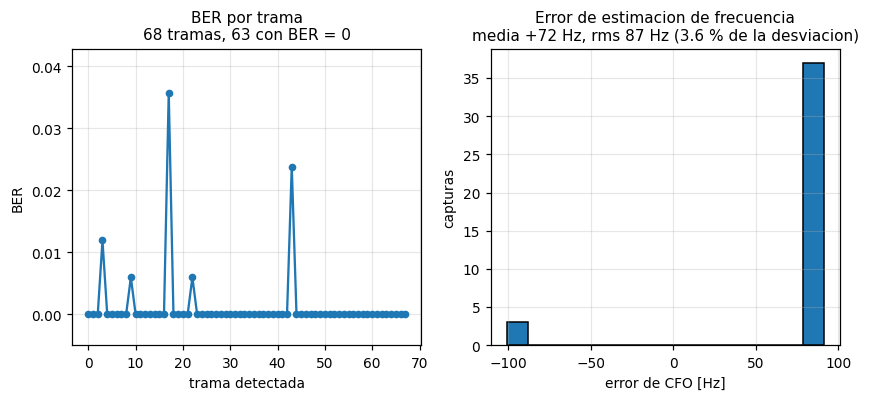

Capturas con trama detectada : 40/40 (100 %)
Tramas demoduladas           : 68 (11424 bits)
Errores de bit totales       : 14
BER media                    : 1.23e-03


In [12]:
# ============================================================
# CELDA 13 — FIGURA 10: estadisticas sobre N capturas
# ============================================================
N_CAPTURAS = 40

est = dict(ber=[], cfo=[], det=0, tramas=0)
p_tx = np.array(payload_tx, dtype=np.uint8)

for s in range(N_CAPTURAS):
    dd = diagnostico(captura(s))
    est['cfo'].append(dd['f_est'] - CFO_REAL)
    if not dd['payloads']:
        continue
    est['det'] += 1
    for pl in dd['payloads']:
        est['tramas'] += 1
        est['ber'].append(float(np.mean(pl != p_tx)))

ber = np.array(est['ber']); cfo = np.array(est['cfo'])
rms_cfo = float(np.sqrt(np.mean(cfo**2)))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].plot(ber, 'o-', ms=4)
ax[0].set_ylim(-0.005, max(0.02, ber.max()*1.2 if ber.size else 0.02))
ax[0].set_xlabel('trama detectada'); ax[0].set_ylabel('BER')
ax[0].set_title(f"BER por trama\n{est['tramas']} tramas, "
                f"{int(np.sum(ber == 0))} con BER = 0")
ax[1].hist(cfo, bins=15, edgecolor='k')
ax[1].set_xlabel('error de CFO [Hz]'); ax[1].set_ylabel('capturas')
ax[1].set_title(f'Error de estimacion de frecuencia\nmedia {cfo.mean():+.0f} Hz, '
                f'rms {rms_cfo:.0f} Hz ({100*rms_cfo/(BAUD/4):.1f} % de la desviacion)')

plt.show()

M_EST = dict(capturas=N_CAPTURAS, detectadas=est['det'],
             tasa_deteccion_pct=100*est['det']/N_CAPTURAS,
             tramas=est['tramas'], bits=est['tramas']*N_PAYLOAD,
             errores=int(round(ber.sum()*N_PAYLOAD)), ber_media=float(ber.mean()),
             cfo_rms_Hz=rms_cfo)
print(f"Capturas con trama detectada : {est['det']}/{N_CAPTURAS} "
      f"({100*est['det']/N_CAPTURAS:.0f} %)")
print(f"Tramas demoduladas           : {est['tramas']} "
      f"({est['tramas']*N_PAYLOAD} bits)")
print(f"Errores de bit totales       : {int(round(ber.sum()*N_PAYLOAD))}")
print(f"BER media                    : {ber.mean():.2e}")

Piso de ruido medido (TX apagado): P_ruido = 5.960e+07

  amplitud x0.00  SNR est.  20.4 dB: deteccion 14/15, 24 tramas,   18 errores en  4032 bits
  amplitud x0.00  SNR est.  28.6 dB: deteccion 15/15, 24 tramas,    0 errores en  4032 bits
  amplitud x0.01  SNR est.  38.1 dB: deteccion 15/15, 24 tramas,    1 errores en  4032 bits
  amplitud x0.01  SNR est.  44.4 dB: deteccion 15/15, 26 tramas,    4 errores en  4368 bits
  amplitud x0.02  SNR est.  50.6 dB: deteccion 15/15, 27 tramas,    8 errores en  4536 bits
  amplitud x0.04  SNR est.  56.7 dB: deteccion 15/15, 26 tramas,    4 errores en  4368 bits
  amplitud x0.08  SNR est.  62.7 dB: deteccion 15/15, 26 tramas,    4 errores en  4368 bits
  amplitud x0.15  SNR est.  68.2 dB: deteccion 15/15, 26 tramas,    0 errores en  4368 bits
  amplitud x0.30  SNR est.  74.2 dB: deteccion 15/15, 26 tramas,    0 errores en  4368 bits
  amplitud x0.50  SNR est.  78.7 dB: deteccion 15/15, 24 tramas,    0 errores en  4032 bits
  amplitud x0.70  SNR es

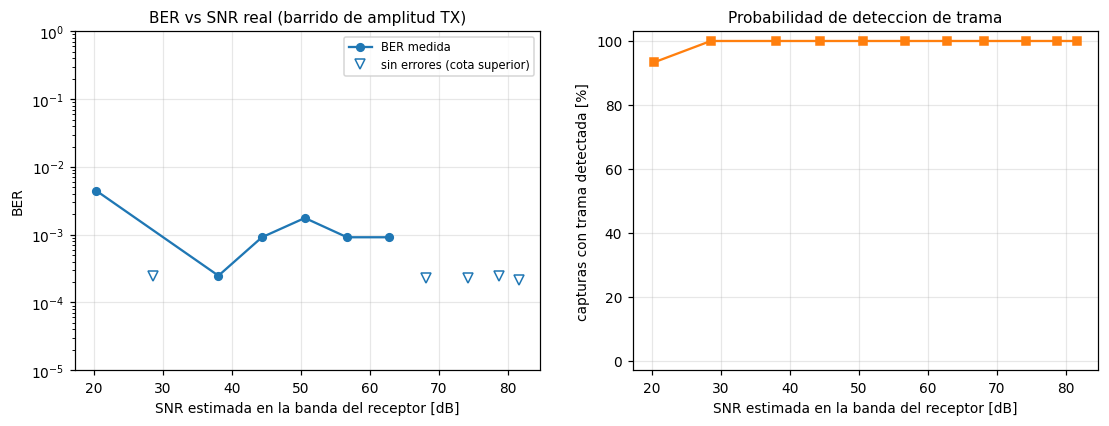


BER = 0 a partir de 29 dB de SNR estimada
Deteccion del 100% a partir de 29 dB

(SNR estimada a partir de la potencia realmente recibida en cada corrida contra el piso de ruido medido con TX apagado.)


In [13]:
# ============================================================
# CELDA 14 — FIGURA 11: barrido de amplitud
# ============================================================


AMPLITUDES_REL = [0.001, 0.002, 0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.3, 0.5, 0.7]  # fraccion de AMPLITUD
N_CAP_SNR = 15

AMPLITUD_ORIG = AMPLITUD
words_orig = words_tx.copy()

# --- piso de ruido real, con el TX detenido ---
tx_stop(sock)
iq_ruido = read_adc(sock, N_RX)
P_ruido = float(np.mean(np.abs(iq_ruido - np.mean(iq_ruido))**2))
print(f"Piso de ruido medido (TX apagado): P_ruido = {P_ruido:.3e}\n")

barr = []
for amp_rel in AMPLITUDES_REL:
    AMPLITUD = amp_rel * AMPLITUD_ORIG
    words_amp, _, _, _ = construir_buffer_dac(bits_trama)
    tx_load_and_start(sock, words_amp)

    det = errs = nbits = nfr = 0
    p_sen = []
    for s in range(N_CAP_SNR):
        iq = read_adc(sock, N_RX)
        m = np.abs(iq); activo = m > 0.5 * np.max(m)
        if np.any(activo):
            p_sen.append(float(np.mean(np.abs(iq[activo] - np.mean(iq))**2)))
        rx_ = RxGmskCiego((iq / (np.max(np.abs(iq)) + 1e-12)).astype(np.complex64),
                          SPS_RX)
        rx_.run()
        pls = rx_.payloads()
        det += bool(pls)
        for pl in pls:
            nfr += 1
            errs += int(np.sum(pl != p_tx))
            nbits += N_PAYLOAD

    snr_est = 10*np.log10(np.mean(p_sen)/P_ruido) if p_sen else np.nan
    barr.append((snr_est, det/N_CAP_SNR, errs/nbits if nbits else np.nan, nfr, nbits))
    print(f"  amplitud x{amp_rel:.2f}  SNR est. {snr_est:5.1f} dB: "
          f"deteccion {det:2d}/{N_CAP_SNR}, {nfr:2d} tramas, "
          f"{errs:4d} errores en {nbits:5d} bits")

# --- restaurar el buffer/amplitud original ---
AMPLITUD = AMPLITUD_ORIG
tx_load_and_start(sock, words_orig)

snr_v = np.array([b[0] for b in barr]); pdet = np.array([b[1] for b in barr])
ber_v = np.array([b[2] for b in barr]); nb_v = np.array([b[4] for b in barr])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
m = ber_v > 0
ax[0].semilogy(snr_v[m], ber_v[m], 'o-', ms=5, label='BER medida')
cota = 1.0/np.maximum(nb_v, 1)
ax[0].semilogy(snr_v[~m], cota[~m], 'v', ms=6, color='C0', mfc='none',
               label='sin errores (cota superior)')
ax[0].set_xlabel('SNR estimada en la banda del receptor [dB]')
ax[0].set_ylabel('BER'); ax[0].set_ylim(1e-5, 1)
ax[0].set_title('BER vs SNR real (barrido de amplitud TX)')
ax[0].legend(fontsize=7.5)

ax[1].plot(snr_v, 100*pdet, 's-', ms=5, color='C1')
ax[1].set_xlabel('SNR estimada en la banda del receptor [dB]')
ax[1].set_ylabel('capturas con trama detectada [%]')
ax[1].set_ylim(-3, 103); ax[1].set_title('Probabilidad de deteccion de trama')

plt.show()

sin_err = snr_v[[i for i, b in enumerate(barr) if b[4] > 0 and b[2] == 0]]
det100 = snr_v[pdet >= 1.0]
M_SNR = dict(snr_ber_cero_dB=float(sin_err.min()) if sin_err.size else None,
             snr_deteccion_100_dB=float(det100.min()) if det100.size else None)
print(f"\nBER = 0 a partir de "
      f"{'%.0f' % M_SNR['snr_ber_cero_dB'] if M_SNR['snr_ber_cero_dB'] is not None else 'n/d'} "
      f"dB de SNR estimada")
print(f"Deteccion del 100% a partir de "
      f"{'%.0f' % M_SNR['snr_deteccion_100_dB'] if M_SNR['snr_deteccion_100_dB'] is not None else 'n/d'} dB")
print("\n(SNR estimada a partir de la potencia realmente recibida en cada "
      "corrida contra el piso de ruido medido con TX apagado.)")

In [14]:
# ============================================================
# CELDA 15 — Resumen de metricas para el informe
# ============================================================
filas = [
    ('Tasa de simbolo',            f"{BAUD/1e3:.1f} kbit/s",      "AIS: 9.6 kbit/s"),
    ('Producto BT',                f"{BT}",                       "AIS: 0.4"),
    ('Ancho de banda 99 %',        f"{M_ESP['bw99_kHz']:.1f} kHz", "canal AIS: 25 kHz"),
    ('Potencia fuera del canal',   f"{M_ESP['potencia_fuera_canal_dBc']:.0f} dBc",
                                                                  "fuera de +-12.5 kHz"),
    ('Longitud de ranura',         f"{N_RANURA} bits / {N_RANURA/BAUD*1e3:.2f} ms",
                                                                  "AIS: 256 bits / 26.67 ms"),
    ('Error de CFO (rms)',         f"{M_EST['cfo_rms_Hz']:.0f} Hz",
                                   f"{100*M_EST['cfo_rms_Hz']/(BAUD/4):.1f} % de la desviacion"),
    ('Niveles de decision',        f"{M_OJO['nivel_0']:+.2f} / {M_OJO['nivel_1']:+.2f}", ""),
    ('Margen minimo de decision',  f"{M_OJO['margen_minimo']:.2f}", "nivel nominal 1.0"),
    ('Tasa de deteccion de trama', f"{M_EST['tasa_deteccion_pct']:.0f} %",
                                   f"{M_EST['detectadas']}/{M_EST['capturas']} capturas"),
    ('Tramas demoduladas',         f"{M_EST['tramas']}",          f"{M_EST['bits']} bits"),
    ('Errores de bit',             f"{M_EST['errores']}",         f"BER = {M_EST['ber_media']:.1e}"),
    ('SNR para BER = 0',
     f"{M_SNR['snr_ber_cero_dB']:.0f} dB" if M_SNR['snr_ber_cero_dB'] is not None else "n/d",
     f"Eb/N0 {M_SNR['snr_ber_cero_dB']+10*np.log10(fs_out/BAUD):.0f} dB"
     if M_SNR['snr_ber_cero_dB'] is not None else "ningun nivel probado dio BER=0"),
    ('SNR para deteccion 100 %',
     f"{M_SNR['snr_deteccion_100_dB']:.0f} dB" if M_SNR['snr_deteccion_100_dB'] is not None else "n/d",
     ""),
]

anchos = [max(len(str(f[i])) for f in filas) for i in range(3)]
print(f"{'Metrica'.ljust(anchos[0])} | {'Valor'.ljust(anchos[1])} | Referencia")
print('-'*(anchos[0]+anchos[1]+anchos[2]+6))
for a, b_, c in filas:
    print(f"{a.ljust(anchos[0])} | {b_.ljust(anchos[1])} | {c}")

with open(f'{DIR_FIG}/metricas.md', 'w') as fh:
    fh.write('| Metrica | Valor | Referencia |\n|---|---|---|\n')
    for a, b_, c in filas:
        fh.write(f'| {a} | {b_} | {c} |\n')
print(f"\nTabla guardada en {DIR_FIG}/metricas.md")

# ---------------- cierre de la conexion con la Red Pitaya ----------------
tx_stop(sock)
sock.close()
print("\nTX detenido, conexion cerrada.")

Metrica                    | Valor               | Referencia
---------------------------------------------------------------------------
Tasa de simbolo            | 9.6 kbit/s          | AIS: 9.6 kbit/s
Producto BT                | 0.4                 | AIS: 0.4
Ancho de banda 99 %        | 9.7 kHz             | canal AIS: 25 kHz
Potencia fuera del canal   | -61 dBc             | fuera de +-12.5 kHz
Longitud de ranura         | 224 bits / 23.33 ms | AIS: 256 bits / 26.67 ms
Error de CFO (rms)         | 87 Hz               | 3.6 % de la desviacion
Niveles de decision        | -0.85 / +0.84       | 
Margen minimo de decision  | 0.73                | nivel nominal 1.0
Tasa de deteccion de trama | 100 %               | 40/40 capturas
Tramas demoduladas         | 68                  | 11424 bits
Errores de bit             | 14                  | BER = 1.2e-03
SNR para BER = 0           | 29 dB               | Eb/N0 42 dB
SNR para deteccion 100 %   | 29 dB               | 

Tabla guardada 